1. ENVIRONMENT SETUP & DEPENDENCIES

In [ ]:
# Install the specific version to match your PC
!pip install scikit-learn==1.5.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 130.2 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.9.post2 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


In [ ]:

!pip -q install pandas numpy scikit-learn textstat wordfreq spacy matplotlib seaborn nltk xgboost
!python -m spacy download en_core_web_md

import pandas as pd
import numpy as np
import glob
import os
import warnings
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import textstat
from wordfreq import zipf_frequency
import nltk
from nltk.corpus import stopwords

# Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import xgboost as xgb

# ML Utils
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, roc_auc_score, roc_curve, precision_recall_curve)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, learning_curve, cross_val_score

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
nltk.download('stopwords', quiet=True)

print("✅ Environment Ready. Loaded ML Libraries.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.4/176.4 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 821.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.0/183.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 56.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ Environment Ready. Loaded ML Li

2. DATA LOADING & CLEANING

In [ ]:
# Load SpaCy Medium model (Vectors included for Semantic Theory)
try:
    nlp = spacy.load("en_core_web_md")
    print("✅ Loaded spaCy 'en_core_web_md' (Semantic Vectors Enabled)")
except OSError:
    print("⚠️ Downloading model...")
    import spacy.cli
    spacy.cli.download("en_core_web_md")
    nlp = spacy.load("en_core_web_md")

# Download Dataset if missing
if not os.path.exists('cwi2018'):
    print("📥 Downloading CWI 2018 Dataset...")
    !wget -q -O cwi2018.zip "https://www.inf.uni-hamburg.de/en/inst/ab/lt/resources/data/complex-word-identification-dataset/cwishareddataset.zip"
    !unzip -q cwi2018.zip -d cwi2018

def load_and_clean_data():
    # Helper to read the TSV format
    def _read_tsv(path):
        try:
            return pd.read_csv(path, sep='\t', encoding='utf-8',
                             names=['sentence', 'start', 'end', 'target',
                                    'nat', 'non_nat', 'nat_complex', 'non_nat_complex',
                                    'label_binary', 'prob'])
        except: return pd.DataFrame()

    # Load all files
    train_files = glob.glob("cwi2018/traindevset/english/*_Train.tsv")
    dev_files = glob.glob("cwi2018/traindevset/english/*_Dev.tsv")

    train_df = pd.concat([_read_tsv(f) for f in train_files], ignore_index=True)
    dev_df = pd.concat([_read_tsv(f) for f in dev_files], ignore_index=True)

    # Cleaning
    for df in [train_df, dev_df]:
        df['label_binary'] = pd.to_numeric(df['label_binary'], errors='coerce').fillna(0).astype(int)
        df['target'] = df['target'].astype(str)
        df['sentence'] = df['sentence'].astype(str)
        df.dropna(subset=['target', 'sentence'], inplace=True)

    return train_df, dev_df

train_df, dev_df = load_and_clean_data()
print(f"✅ Data Loaded. Train: {train_df.shape}, Dev: {dev_df.shape}")

✅ Loaded spaCy 'en_core_web_md' (Semantic Vectors Enabled)
📥 Downloading CWI 2018 Dataset...
✅ Data Loaded. Train: (27299, 10), Dev: (3328, 10)


3. ADVANCED FEATURE ENGINEERING (Refining Theory)

In [ ]:
# We define a robust feature extractor that covers:
# 1. Morphology (Structure)
# 2. Linguistics (Grammar)
# 3. Semantics (Meaning)
# 4. Statistics (Frequency)

STOP_WORDS = set(stopwords.words("english"))

def get_token_features(row, nlp_docs):
    doc = nlp_docs.get(row['sentence'])
    if not doc: return None

    # Attempt to find the token
    target = None
    for token in doc:
        # Flexible matching
        if token.text == row['target'] or row['target'] in token.text:
            target = token
            break

    if not target:
        # Default values for missing tokens
        return [0, 0, 0.0, 'UNK', 'UNK'] # is_ent, is_title, vector_norm, pos, dep

    return [
        1 if target.ent_type_ else 0,    # Is Named Entity?
        1 if target.is_title else 0,     # Is Title Case?
        target.vector_norm,              # Semantic Magnitude (Crucial for abstract words)
        target.pos_,                     # Part of Speech
        target.dep_                      # Dependency Label
    ]

def extract_features(df):
    print(f"⚙️ Extracting Features for {len(df)} samples...")
    features = pd.DataFrame(index=df.index)

    # --- A. Statistical & Morphological ---
    features['char_len'] = df['target'].str.len()
    features['syllables'] = df['target'].apply(textstat.syllable_count)
    features['zipf_freq'] = df['target'].apply(lambda x: zipf_frequency(x, 'en'))
    features['is_stopword'] = df['target'].str.lower().isin(STOP_WORDS).astype(int)
    features['vowel_count'] = df['target'].str.count(r'[aeiouAEIOU]')
    features['consonant_count'] = features['char_len'] - features['vowel_count']

    # --- B. Semantic & Linguistic (Batch Processed) ---
    unique_sents = df['sentence'].unique()
    # Batch process with spaCy for speed
    docs = {sent: doc for sent, doc in zip(unique_sents, nlp.pipe(unique_sents, batch_size=200))}

    # Apply per row
    linguistic_data = df.apply(lambda row: get_token_features(row, docs), axis=1)

    # Unpack list into columns
    features['is_ent'] = linguistic_data.apply(lambda x: x[0])
    features['is_title'] = linguistic_data.apply(lambda x: x[1])
    features['vector_norm'] = linguistic_data.apply(lambda x: x[2])
    features['pos'] = linguistic_data.apply(lambda x: x[3])
    features['dep'] = linguistic_data.apply(lambda x: x[4])

    return features

X_train_raw = extract_features(train_df)
y_train = train_df['label_binary'].values
X_dev_raw = extract_features(dev_df)
y_dev = dev_df['label_binary'].values

print(f"✅ Feature Extraction Complete. Feature Count: {X_train_raw.shape[1]}")

⚙️ Extracting Features for 27299 samples...
⚙️ Extracting Features for 3328 samples...
✅ Feature Extraction Complete. Feature Count: 11


4. MODEL SELECTION

In [ ]:
# Prepare Preprocessing Pipeline
numeric_features = X_train_raw.select_dtypes(include=np.number).columns.tolist()
categorical_features = ['pos', 'dep']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

# Define Candidates
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "XGBoost": xgb.XGBClassifier(eval_metric='logloss', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM (RBF)": SVC(probability=True, class_weight='balanced', random_state=42)
}

print("\n⚔️ STARTING MODEL COMPARISON (5-Fold CV)...")
print("-" * 50)
best_score = 0
best_model_name = ""

results = {}

for name, model in models.items():
    # Create full pipeline
    clf = Pipeline([('preprocessor', preprocessor), ('classifier', model)])

    # Cross Validate (F1 Score is better for imbalanced data like this)
    cv_scores = cross_val_score(clf, X_train_raw, y_train, cv=5, scoring='f1_macro', n_jobs=-1)
    avg_score = np.mean(cv_scores)
    results[name] = avg_score

    print(f"Assessment: {name:20} | F1 Score: {avg_score:.4f}")

    if avg_score > best_score:
        best_score = avg_score
        best_model_name = name

print("-" * 50)
print(f"🏆 WINNER: {best_model_name} (F1: {best_score:.4f})")
print("-" * 50)


⚔️ STARTING MODEL COMPARISON (5-Fold CV)...
--------------------------------------------------
Assessment: Logistic Regression  | F1 Score: 0.7920
Assessment: Random Forest        | F1 Score: 0.8122
Assessment: XGBoost              | F1 Score: 0.8217
Assessment: Gradient Boosting    | F1 Score: 0.8148
Assessment: SVM (RBF)            | F1 Score: 0.8133
--------------------------------------------------
🏆 WINNER: XGBoost (F1: 0.8217)
--------------------------------------------------


5. HYPERPARAMETER TUNING (For the Winner)

In [ ]:
print(f"\n🔧 Tuning Hyperparameters for {best_model_name}...")

# Define parameter grids for likely winners
param_grids = {
    "Random Forest": {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [10, 20, None],
        'classifier__min_samples_split': [2, 5]
    },
    "XGBoost": {
        'classifier__learning_rate': [0.01, 0.1],
        'classifier__max_depth': [3, 6, 10],
        'classifier__n_estimators': [100, 300],
        'classifier__subsample': [0.8, 1.0] # Helps prevent overfitting
    },
    "Gradient Boosting": {
        'classifier__learning_rate': [0.05, 0.1],
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [3, 5]
    },
    "SVM (RBF)": {
        'classifier__C': [0.1, 1, 10],
        'classifier__gamma': ['scale', 'auto']
    },
    "Logistic Regression": {
        'classifier__C': [0.1, 1, 10]
    }
}

winner_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', models[best_model_name])
])

grid = GridSearchCV(
    winner_pipeline,
    param_grids[best_model_name],
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_raw, y_train)
final_model = grid.best_estimator_

print(f"\n✅ Best Parameters Found: {grid.best_params_}")


🔧 Tuning Hyperparameters for XGBoost...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

✅ Best Parameters Found: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 10, 'classifier__n_estimators': 300, 'classifier__subsample': 0.8}


6. PERFORMANCE GRAPHS


📊 Generating Comprehensive Evaluation Plots...


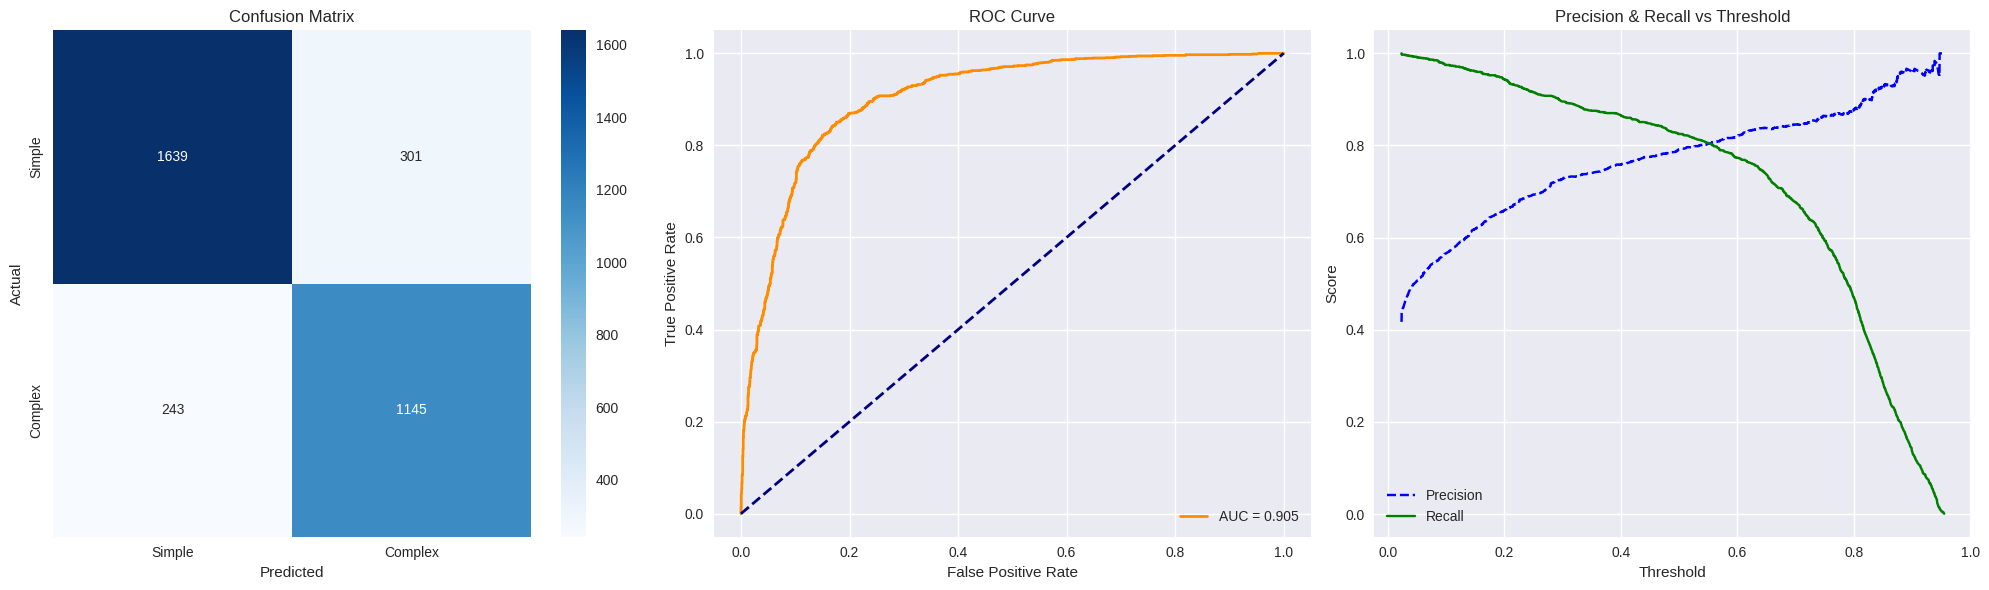

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_performance_graphs(model, X_val, y_val):
    # 1. Get Predictions
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # --- GRAPH 1: Confusion Matrix ---
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Simple', 'Complex'],
                yticklabels=['Simple', 'Complex'])
    axes[0].set_title('Confusion Matrix')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    # --- GRAPH 2: ROC Curve ---
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    roc_auc = roc_auc_score(y_val, y_proba)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_title('ROC Curve')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend(loc="lower right")
    axes[1].grid(True)

    # --- GRAPH 3: Precision-Recall vs Threshold ---
    precisions, recalls, thresholds = precision_recall_curve(y_val, y_proba)
    axes[2].plot(thresholds, precisions[:-1], 'b--', label='Precision')
    axes[2].plot(thresholds, recalls[:-1], 'g-', label='Recall')
    axes[2].set_title('Precision & Recall vs Threshold')
    axes[2].set_xlabel('Threshold')
    axes[2].set_ylabel('Score')
    axes[2].legend(loc='best')
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

# Run the plotter
print("\n📊 Generating Comprehensive Evaluation Plots...")
plot_performance_graphs(final_model, X_dev_raw, y_dev)

7. EVALUATION & VALIDATION


📊 FINAL EVALUATION REPORT
              precision    recall  f1-score   support

           0       0.87      0.84      0.86      1940
           1       0.79      0.82      0.81      1388

    accuracy                           0.84      3328
   macro avg       0.83      0.83      0.83      3328
weighted avg       0.84      0.84      0.84      3328

AUC-ROC Score: 0.9046

📈 Generating Learning Curve (Proof of Fit)...


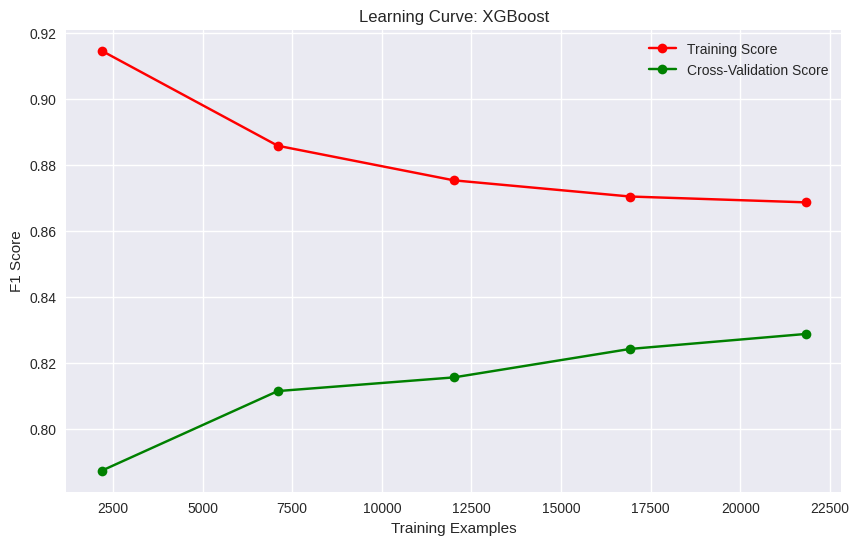


💾 Exporting Manual Validation File...
✅ Saved 'manual_validation_errors.csv' with 544 discrepancies for manual review.
✅ Full Pipeline Complete.
✅ Model Saved to 'best_cwi_model.pkl'


In [ ]:
# A. Test Set Evaluation
# Use the raw features (X_dev_raw) because the pipeline handles the preprocessing
y_pred = final_model.predict(X_dev_raw)
y_proba = final_model.predict_proba(X_dev_raw)[:, 1]

print("\n📊 FINAL EVALUATION REPORT")
print("=" * 40)
print(classification_report(y_dev, y_pred))
print(f"AUC-ROC Score: {roc_auc_score(y_dev, y_proba):.4f}")

# B. Learning Curve (Overfitting Check)
print("\n📈 Generating Learning Curve (Proof of Fit)...")

# Note: We use the pipeline 'final_model' here
train_sizes, train_scores, test_scores = learning_curve(
    final_model, X_train_raw, y_train, cv=5, scoring='f1_macro', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', color="r", label="Training Score")
plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', color="g", label="Cross-Validation Score")
plt.title(f"Learning Curve: {best_model_name}")
plt.xlabel("Training Examples")
plt.ylabel("F1 Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()

# C. Manual Validation Export
print("\n💾 Exporting Manual Validation File...")
validation_df = dev_df.copy()
validation_df['predicted_complex'] = y_pred
validation_df['confidence'] = y_proba

# Filter for errors (False Positives & False Negatives)
errors = validation_df[validation_df['label_binary'] != validation_df['predicted_complex']]
errors_sample = errors[['target', 'sentence', 'label_binary', 'predicted_complex', 'confidence']]
errors_sample.to_csv('manual_validation_errors.csv', index=False)

print(f"✅ Saved 'manual_validation_errors.csv' with {len(errors)} discrepancies for manual review.")
print("✅ Full Pipeline Complete.")

# Save the best model
joblib.dump(final_model, 'best_cwi_model.pkl')
print("✅ Model Saved to 'best_cwi_model.pkl'")

8. FINAL TESTING: REAL-WORLD DEMO

In [ ]:
def analyze_paragraph(text, model, top_n=10, threshold=0.4):
    """
    End-to-end testing function:
    1. Tokenizes raw text
    2. Extracts features (Morphology + Semantics)
    3. Predicts complexity using the trained model
    4. Returns top complex words
    """
    print(f"\n📝 Analyzing Paragraph ({len(text)} characters)...")

    # 1. Process Text with SpaCy
    doc = nlp(text)

    # 2. Create Data Structure for Model
    # We must match the EXACT format used in training
    rows = []
    for sent in doc.sents:
        for token in sent:
            # Filter out punctuation and simple whitespace to save processing
            if not token.is_alpha:
                continue

            rows.append({
                'target': token.text,
                'sentence': sent.text,
                # Dummy labels needed to make the feature extractor work
                'label_binary': 0
            })

    if not rows:
        print("⚠️ No valid words found in text.")
        return

    test_df = pd.DataFrame(rows)

    # 3. Extract Features (Re-using your robust engineer pipeline)
    # Note: This uses the 'extract_features' function defined earlier
    try:
        X_test = extract_features(test_df)
    except Exception as e:
        print(f"Feature extraction error: {e}")
        return

    # 4. Predict Probabilities
    # We use predict_proba to get the "Confidence Score"
    probs = model.predict_proba(X_test)[:, 1]

    # 5. Rank & Filter
    test_df['complexity_score'] = probs

    # Filter: Score > Threshold AND not a stopword (optional cleanup)
    complex_words = test_df[
        (test_df['complexity_score'] > threshold) &
        (~test_df['target'].str.lower().isin(STOP_WORDS))
    ].copy()

    # Sort by highest complexity score
    top_words = complex_words.sort_values('complexity_score', ascending=False).drop_duplicates(subset=['target'])

    # 6. Display Results
    print("\n" + "="*40)
    print(f"🔍 TOP {top_n} IDENTIFIED COMPLEX WORDS")
    print("="*40)

    if top_words.empty:
        print("✅ No complex words found! This text appears simple.")
    else:
        print(f"{'WORD':<20} | {'CONFIDENCE':<10} | {'SYLLABLES'}")
        print("-" * 45)
        for idx, row in top_words.head(top_n).iterrows():
            syl_count = textstat.syllable_count(row['target'])
            print(f"{row['target']:<20} | {row['complexity_score']:.2%}     | {syl_count}")

    return top_words

# --- TEST CASES ---

# Case 1: Scientific / Academic Text
text_science = """
Quantum entanglement is a physical phenomenon that occurs when a group of particles
are generated, interacting, or sharing spatial proximity in a way such that the
quantum state of each particle of the group cannot be described independently
of the state of the others, including when the particles are separated by a large distance.
"""

# Case 2: Business / Formal Text
text_business = """
The conglomerate announced a strategic consolidation of its assets to mitigate
liquidity risks during the upcoming fiscal quarter. Stakeholders were advised
to review the prospectus thoroughly before exercising their stock options.
"""

# Run the Demo
print("\n--- 🧪 TEST CASE 1: QUANTUM PHYSICS ---")
analyze_paragraph(text_science, final_model)

print("\n--- 🧪 TEST CASE 2: BUSINESS FINANCE ---")
analyze_paragraph(text_business, final_model)


--- 🧪 TEST CASE 1: QUANTUM PHYSICS ---

📝 Analyzing Paragraph (335 characters)...
⚙️ Extracting Features for 55 samples...

🔍 TOP 10 IDENTIFIED COMPLEX WORDS
WORD                 | CONFIDENCE | SYLLABLES
---------------------------------------------
entanglement         | 95.14%     | 4
independently        | 90.96%     | 5
interacting          | 89.22%     | 4
phenomenon           | 89.20%     | 4
proximity            | 89.14%     | 4
particle             | 85.20%     | 3
generated            | 84.29%     | 4
spatial              | 83.70%     | 2
particles            | 79.61%     | 3
separated            | 79.38%     | 4

--- 🧪 TEST CASE 2: BUSINESS FINANCE ---

📝 Analyzing Paragraph (233 characters)...
⚙️ Extracting Features for 31 samples...

🔍 TOP 10 IDENTIFIED COMPLEX WORDS
WORD                 | CONFIDENCE | SYLLABLES
---------------------------------------------
conglomerate         | 94.78%     | 4
liquidity            | 93.32%     | 4
prospectus           | 93.10%     | 3
Sta

,target,sentence,label_binary,complexity_score
1,conglomerate,\nThe conglomerate announced a strategic conso...,0,0.947850
11,liquidity,\nThe conglomerate announced a strategic conso...,0,0.933153
24,prospectus,Stakeholders were advised\nto review the prosp...,0,0.930991
18,Stakeholders,Stakeholders were advised\nto review the prosp...,0,0.925713
5,consolidation,\nThe conglomerate announced a strategic conso...,0,0.921745
10,mitigate,\nThe conglomerate announced a strategic conso...,0,0.888960
27,exercising,Stakeholders were advised\nto review the prosp...,0,0.885496
4,strategic,\nThe conglomerate announced a strategic conso...,0,0.882484
25,thoroughly,Stakeholders were advised\nto review the prosp...,0,0.851938
2,announced,\nThe conglomerate announced a strategic conso...,0,0.810624
